# 02 - Validación interna y sensibilidad de diarización

Este notebook fusiona el análisis de solapamiento de anchors y la sensibilidad del margen de reetiquetado (`RELABEL_MIN_MARGIN`).

Su objetivo es documentar y justificar decisiones internas del pipeline sin recalcular diarización ni modificar los CSVs originales del Notebook 01.

In [1]:
%pip install -q -r ~/TFM_ProcesadoDeAudios/requirements.txt

print("Requisitos instalados correctamente.")

Note: you may need to restart the kernel to use updated packages.
Requisitos instalados correctamente.


## 1. Imports

In [2]:
from pathlib import Path
import os
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.cloud import storage
    GCS_AVAILABLE = True
except Exception:
    GCS_AVAILABLE = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

print("Imports cargados correctamente.")
print(f"GCS disponible: {GCS_AVAILABLE}")

Imports cargados correctamente.
GCS disponible: True


## 2. Configuración de rutas y parámetros

In [3]:
# =========================
# CONFIGURACIÓN DE RUTAS
# =========================

# Ruta base del proyecto en la VM
PROJECT_DIR = Path("/home/jupyter/TFM_ProcesadoDeAudios")

# Carpeta principal de outputs de diarización
OUTPUT_DIR = PROJECT_DIR / "data" / "diarization_outputs"

# Carpeta donde el notebook de diarización guarda los resultados finales por audio
FINAL_RELABEL_DIR = OUTPUT_DIR / "final_relabel"

# Prefijo GCS de outputs de diarización
GCS_DIARIZATION_OUTPUT_PREFIX = "gs://catedras_audio_detection/pipelineA/procesados_UNAV/diarization_outputs/"

# =========================
# ARCHIVOS PRINCIPALES DE DIARIZACIÓN
# =========================

SCORED_SEGMENTS_CSV = OUTPUT_DIR / "diarization_all_scored_segments.csv"
ANCHOR_SEGMENTS_CSV = OUTPUT_DIR / "diarization_all_anchor_segments.csv"
SUMMARY_CSV = OUTPUT_DIR / "diarization_summary.csv"

FINAL_SEGMENTS_CSV = FINAL_RELABEL_DIR / "all_final_segments.csv"
CHANGED_SEGMENTS_CSV = FINAL_RELABEL_DIR / "all_changed_segments.csv"
RELABEL_SUMMARY_CSV = FINAL_RELABEL_DIR / "relabel_summary.csv"

# =========================
# ANÁLISIS DE OVERLAP / ANCHORS
# =========================

OVERLAP_ANALYSIS_DIR = OUTPUT_DIR / "overlap_analysis"
OVERLAP_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD_SUMMARY_CSV = OVERLAP_ANALYSIS_DIR / "overlap_threshold_summary.csv"
AUDIO_OVERLAP_SUMMARY_CSV = OVERLAP_ANALYSIS_DIR / "audio_overlap_summary.csv"
SEGMENT_OVERLAP_DISTRIBUTION_CSV = OVERLAP_ANALYSIS_DIR / "segment_overlap_distribution.csv"

OVERLAP_THRESHOLDS = [0.00, 0.01, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30]

# =========================
# ANÁLISIS DE SENSIBILIDAD DEL MARGEN DE RELABELING
# =========================

MARGIN_ANALYSIS_DIR = OUTPUT_DIR / "relabel_margin_sensitivity"
MARGIN_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

RELABEL_MARGIN_OPTIONS = [0.00, 0.005, 0.01, 0.02, 0.03, 0.05, 0.10]

# Parámetro usado para unir segmentos finales consecutivos
MAX_GAP_MERGE_SEC = 0.50

# Subida opcional a GCS para este análisis auxiliar
UPLOAD_TO_GCS = False
GCS_BUCKET_NAME = "catedras_audio_detection"
GCS_CSV_PREFIX = "pipelineA/procesados_UNAV/csv_outputs/"

# =========================
# PARÁMETROS DEL PIPELINE ORIGINAL
# =========================

NUM_SPEAKERS = 2
ANCHORS_PER_SPEAKER = 3

MIN_SEGMENT_DURATION_SEC = 0.70
MIN_RMS_DBFS = -40.0

MIN_ANCHOR_DURATION_SEC = 1.20
INITIAL_EXCLUDE_SEC_FOR_ANCHORS = 1.50

ANONYMIZATION_SALT = os.environ.get(
    "TFM_ANONYMIZATION_SALT",
    "tfm_local_salt_not_for_final_release"
)

# =========================
# CONTROL DE CONFIGURACIÓN
# =========================

print("Configuración cargada.")
print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"FINAL_RELABEL_DIR: {FINAL_RELABEL_DIR}")
print(f"OVERLAP_ANALYSIS_DIR: {OVERLAP_ANALYSIS_DIR}")
print(f"MARGIN_ANALYSIS_DIR: {MARGIN_ANALYSIS_DIR}")
print(f"Márgenes a probar: {RELABEL_MARGIN_OPTIONS}")
print(f"Umbrales de overlap: {OVERLAP_THRESHOLDS}")

Configuración cargada.
PROJECT_DIR: /home/jupyter/TFM_ProcesadoDeAudios
OUTPUT_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs
FINAL_RELABEL_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs/final_relabel
OVERLAP_ANALYSIS_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs/overlap_analysis
MARGIN_ANALYSIS_DIR: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs/relabel_margin_sensitivity
Márgenes a probar: [0.0, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1]
Umbrales de overlap: [0.0, 0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3]


## 3. Funciones auxiliares

In [4]:
# =========================
# FUNCIONES AUXILIARES
# =========================

def split_gcs_uri(gcs_uri: str):
    if not gcs_uri.startswith("gs://"):
        raise ValueError("La ruta debe empezar por 'gs://'")
    path = gcs_uri[5:]
    bucket_name, _, prefix = path.partition("/")
    return bucket_name, prefix


def download_if_missing_from_gcs(local_path: Path, gcs_prefix: str):
    if local_path.exists():
        return False

    if not GCS_AVAILABLE:
        raise FileNotFoundError(f"No existe localmente y GCS no está disponible: {local_path}")

    bucket_name, prefix = split_gcs_uri(gcs_prefix)
    relative_path = local_path.relative_to(OUTPUT_DIR).as_posix()
    blob_path = f"{prefix}{relative_path}"

    local_path.parent.mkdir(parents=True, exist_ok=True)

    client = storage.Client()
    blob = client.bucket(bucket_name).blob(blob_path)

    if not blob.exists():
        raise FileNotFoundError(f"No existe en GCS: gs://{bucket_name}/{blob_path}")

    blob.download_to_filename(str(local_path))
    return True


def upload_file_to_gcs(local_path: Path, gcs_prefix: str):
    if not GCS_AVAILABLE:
        print("GCS no disponible. No se sube archivo.")
        return None

    bucket_name, prefix = split_gcs_uri(gcs_prefix)
    relative_path = local_path.relative_to(OUTPUT_DIR).as_posix()
    blob_path = f"{prefix}{relative_path}"

    client = storage.Client()
    blob = client.bucket(bucket_name).blob(blob_path)
    blob.upload_from_filename(str(local_path))

    return f"gs://{bucket_name}/{blob_path}"


def hash_value(value, salt=ANONYMIZATION_SALT):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    return hashlib.sha256(f"{salt}_{value}".encode("utf-8")).hexdigest()[:16]


def safe_rate(numerator, denominator):
    return numerator / denominator if denominator else np.nan

print("Funciones auxiliares cargadas.")

# =========================
# FUNCIONES AUXILIARES PARA SENSIBILIDAD DE MARGEN
# =========================

def find_final_segment_files(final_relabel_dir: Path):
    """
    Busca CSVs por audio generados por el Notebook 01.
    Excluye archivos consolidados globales para no duplicar segmentos.
    """
    files = sorted([
        p for p in final_relabel_dir.glob("*_final_segments.csv")
        if p.name != "all_final_segments.csv"
    ])
    return files


def infer_best_speaker_from_distances(df: pd.DataFrame):
    """
    Recalcula el speaker más cercano a partir de columnas dist_SPEAKER_*.
    Estas distancias ya fueron calculadas por el Notebook 01 con embeddings.
    """
    df = df.copy()

    dist_cols = [c for c in df.columns if c.startswith("dist_")]

    if len(dist_cols) < 2:
        raise ValueError("No hay suficientes columnas dist_SPEAKER_* para recalcular márgenes.")

    dist_values = df[dist_cols].replace([np.inf, -np.inf], np.nan)

    # Speaker con menor distancia al centroide
    best_col = dist_values.idxmin(axis=1)
    best_distance = dist_values.min(axis=1)

    # Segunda menor distancia
    second_distance = dist_values.apply(
        lambda row: row.nsmallest(2).iloc[1] if row.notna().sum() >= 2 else np.nan,
        axis=1,
    )

    df["best_speaker_recomputed"] = best_col.str.replace("dist_", "", regex=False)
    df["best_distance_recomputed"] = best_distance
    df["second_distance_recomputed"] = second_distance
    df["distance_margin_recomputed"] = second_distance - best_distance

    return df


def apply_relabel_margin(df: pd.DataFrame, margin: float):
    """
    Aplica un margen de reetiquetado sin recalcular embeddings.
    Si la ventaja del mejor speaker supera el margen, usa el mejor speaker.
    Si no, conserva el speaker original.
    """
    df = df.copy()

    if "speaker_original" in df.columns:
        original_col = "speaker_original"
    elif "speaker" in df.columns:
        original_col = "speaker"
    else:
        raise ValueError("No existe speaker_original ni speaker en el CSV.")

    valid_margin = df["distance_margin_recomputed"].notna()
    enough_margin = df["distance_margin_recomputed"] >= margin

    df["tested_relabel_margin"] = margin
    df["speaker_final_margin"] = np.where(
        valid_margin & enough_margin,
        df["best_speaker_recomputed"],
        df[original_col],
    )

    df["was_reclassified_margin"] = df["speaker_final_margin"] != df[original_col]

    df["relabel_source_margin"] = np.where(
        valid_margin & enough_margin,
        "centroid_margin_ok",
        "original_low_margin_or_missing",
    )

    df["original_speaker_col_used"] = original_col

    return df


def count_merged_segments(df: pd.DataFrame, speaker_col="speaker_final_margin", max_gap_sec=0.50):
    """
    Cuenta cuántos segmentos quedarían después de unir segmentos consecutivos
    del mismo speaker final separados por una pausa corta.
    No guarda los segmentos unidos; solo cuenta.
    """
    if df.empty:
        return 0

    required_cols = ["start", "end", speaker_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        return np.nan

    df = df.sort_values(["start", "end"]).reset_index(drop=True)

    n_merged = 0
    current_end = None
    current_speaker = None

    for _, row in df.iterrows():
        start = float(row["start"])
        end = float(row["end"])
        speaker = row[speaker_col]

        if current_end is None:
            n_merged = 1
            current_end = end
            current_speaker = speaker
            continue

        gap = start - current_end

        if speaker == current_speaker and gap <= max_gap_sec:
            current_end = max(current_end, end)
        else:
            n_merged += 1
            current_end = end
            current_speaker = speaker

    return n_merged


def upload_outputs_to_gcs(paths, bucket_name, prefix):
    """
    Subida opcional de resultados a GCS. Sobrescribe si ya existe.
    """
    from google.cloud import storage

    client = storage.Client()
    bucket = client.bucket(bucket_name)

    for path in paths:
        path = Path(path)
        if not path.exists():
            print("No existe localmente:", path)
            continue

        blob_name = f"{prefix}{path.name}"
        blob = bucket.blob(blob_name)
        blob.upload_from_filename(str(path))
        print(f"Subido a gs://{bucket_name}/{blob_name}")

Funciones auxiliares cargadas.


## 4. Carga y validación de outputs de diarización

In [5]:
# =========================
# CARGA DE OUTPUTS DE DIARIZACIÓN
# =========================

required_files = [SCORED_SEGMENTS_CSV, ANCHOR_SEGMENTS_CSV, SUMMARY_CSV]

for file_path in required_files:
    downloaded = download_if_missing_from_gcs(file_path, GCS_DIARIZATION_OUTPUT_PREFIX)
    if downloaded:
        print(f"Descargado desde GCS: {file_path.name}")

df_all_scored_segments = pd.read_csv(SCORED_SEGMENTS_CSV)
df_all_anchor_segments = pd.read_csv(ANCHOR_SEGMENTS_CSV)
df_summary = pd.read_csv(SUMMARY_CSV)

# Relabeling opcional
df_final_segments = None
df_changed_segments = None
df_relabel_summary = None

for optional_path, var_name in [
    (FINAL_SEGMENTS_CSV, "df_final_segments"),
    (CHANGED_SEGMENTS_CSV, "df_changed_segments"),
    (RELABEL_SUMMARY_CSV, "df_relabel_summary"),
]:
    try:
        download_if_missing_from_gcs(optional_path, GCS_DIARIZATION_OUTPUT_PREFIX)
        if optional_path.exists():
            if var_name == "df_final_segments":
                df_final_segments = pd.read_csv(optional_path)
            elif var_name == "df_changed_segments":
                df_changed_segments = pd.read_csv(optional_path)
            elif var_name == "df_relabel_summary":
                df_relabel_summary = pd.read_csv(optional_path)
    except Exception as e:
        print(f"No se cargó {optional_path.name}: {e}")

print("Outputs cargados correctamente.")
print(f"Audios en summary: {len(df_summary)}")
print(f"Segmentos puntuados: {len(df_all_scored_segments)}")
print(f"Anchors actuales: {len(df_all_anchor_segments)}")
if df_final_segments is not None:
    print(f"Segmentos finales relabel: {len(df_final_segments)}")

Outputs cargados correctamente.
Audios en summary: 1198
Segmentos puntuados: 73000
Anchors actuales: 7038
Segmentos finales relabel: 43493


In [6]:
# =========================
# VALIDACIÓN DE COLUMNAS
# =========================

required_scored_cols = {
    "audio_file", "audio_stem", "start", "end", "duration", "speaker",
    "rms_dbfs", "overlap_duration_sec", "overlap_ratio", "valid_export"
}
missing_cols = required_scored_cols - set(df_all_scored_segments.columns)
if missing_cols:
    raise ValueError(f"Faltan columnas en df_all_scored_segments: {missing_cols}")

print("Columnas necesarias detectadas correctamente.")
print(df_all_scored_segments.columns.tolist())

Columnas necesarias detectadas correctamente.
['segment_id_raw', 'audio_file', 'audio_stem', 'start', 'end', 'duration', 'speaker', 'rms_dbfs', 'overlap_duration_sec', 'overlap_ratio', 'valid_export', 'valid_anchor', 'drop_reasons', 'anchor_reasons']


## 5. Distribución general de solapamiento por segmento

In [7]:
# =========================
# DISTRIBUCIÓN DE OVERLAP POR SEGMENTO
# =========================

df_segments = df_all_scored_segments.copy()
df_segments["overlap_ratio"] = pd.to_numeric(df_segments["overlap_ratio"], errors="coerce").fillna(0.0)
df_segments["overlap_duration_sec"] = pd.to_numeric(df_segments["overlap_duration_sec"], errors="coerce").fillna(0.0)
df_segments["duration"] = pd.to_numeric(df_segments["duration"], errors="coerce")
df_segments["rms_dbfs"] = pd.to_numeric(df_segments["rms_dbfs"], errors="coerce")

print("Resumen de overlap_ratio en segmentos puntuados:")
print(df_segments["overlap_ratio"].describe())

threshold_rows = []
for threshold in OVERLAP_THRESHOLDS:
    threshold_rows.append({
        "threshold": threshold,
        "n_segments_leq_threshold": int((df_segments["overlap_ratio"] <= threshold).sum()),
        "pct_segments_leq_threshold": float((df_segments["overlap_ratio"] <= threshold).mean()),
        "n_segments_gt_threshold": int((df_segments["overlap_ratio"] > threshold).sum()),
        "pct_segments_gt_threshold": float((df_segments["overlap_ratio"] > threshold).mean()),
    })

df_segment_overlap_distribution = pd.DataFrame(threshold_rows)
df_segment_overlap_distribution.to_csv(SEGMENT_OVERLAP_DISTRIBUTION_CSV, index=False)
df_segment_overlap_distribution

Resumen de overlap_ratio en segmentos puntuados:
count    73000.000000
mean         0.138958
std          0.301492
min          0.000000
25%          0.000000
50%          0.000000
75%          0.063291
max          1.000000
Name: overlap_ratio, dtype: float64


,threshold,n_segments_leq_threshold,pct_segments_leq_threshold,n_segments_gt_threshold,pct_segments_gt_threshold
0,0.00,48208,0.660384,24792,0.339616
1,0.01,49506,0.678164,23494,0.321836
2,0.03,51970,0.711918,21030,0.288082
3,0.05,53777,0.736671,19223,0.263329
4,0.10,56865,0.778973,16135,0.221027
5,0.15,58817,0.805712,14183,0.194288
6,0.20,60269,0.825603,12731,0.174397
7,0.30,62026,0.849671,10974,0.150329


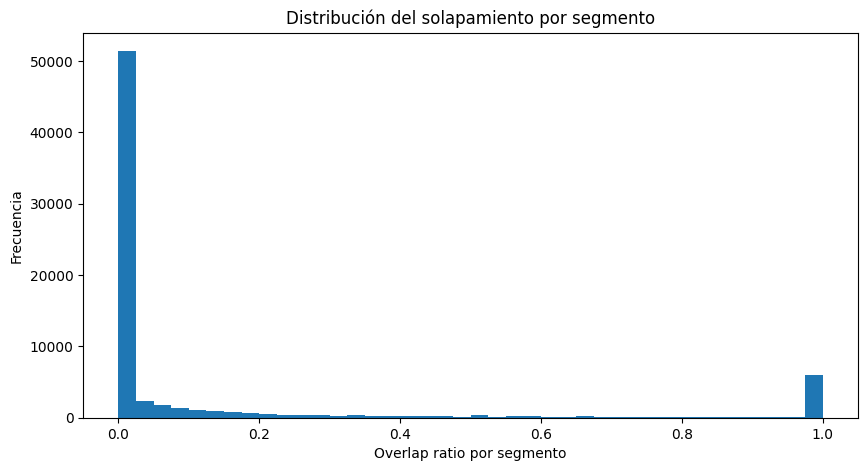

In [8]:
# =========================
# HISTOGRAMA DE OVERLAP_RATIO POR SEGMENTO
# =========================

plt.figure(figsize=(10, 5))
plt.hist(df_segments["overlap_ratio"], bins=40)
plt.xlabel("Overlap ratio por segmento")
plt.ylabel("Frecuencia")
plt.title("Distribución del solapamiento por segmento")
plt.show()

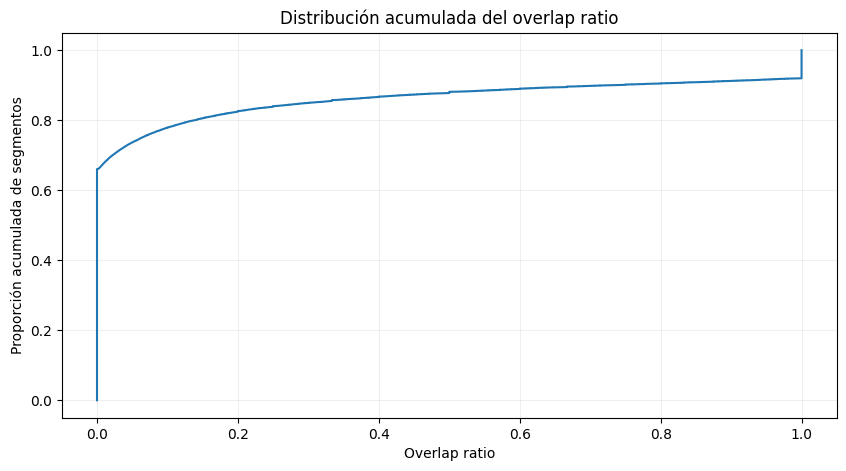

In [9]:
# =========================
# ECDF DE OVERLAP_RATIO POR SEGMENTO
# =========================

overlap_values = np.sort(df_segments["overlap_ratio"].dropna().values)
y_ecdf = np.arange(1, len(overlap_values) + 1) / len(overlap_values)

plt.figure(figsize=(10, 5))
plt.plot(overlap_values, y_ecdf)
plt.xlabel("Overlap ratio")
plt.ylabel("Proporción acumulada de segmentos")
plt.title("Distribución acumulada del overlap ratio")
plt.grid(alpha=0.2)
plt.show()

## 6. Solapamiento por audio

In [10]:
# =========================
# RESUMEN DE OVERLAP POR AUDIO
# =========================

df_audio_overlap_summary = (
    df_segments
    .groupby(["audio_file", "audio_stem"], dropna=False)
    .agg(
        n_segments=("overlap_ratio", "size"),
        mean_overlap_ratio=("overlap_ratio", "mean"),
        median_overlap_ratio=("overlap_ratio", "median"),
        max_overlap_ratio=("overlap_ratio", "max"),
        total_overlap_duration_sec=("overlap_duration_sec", "sum"),
        total_segment_duration_sec=("duration", "sum"),
        n_segments_with_overlap=("overlap_ratio", lambda s: int((s > 0).sum())),
        n_segments_overlap_gt_005=("overlap_ratio", lambda s: int((s > 0.05).sum())),
        n_segments_overlap_gt_010=("overlap_ratio", lambda s: int((s > 0.10).sum())),
        n_segments_overlap_gt_020=("overlap_ratio", lambda s: int((s > 0.20).sum())),
    )
    .reset_index()
)

df_audio_overlap_summary["audio_overlap_ratio_weighted"] = (
    df_audio_overlap_summary["total_overlap_duration_sec"] /
    df_audio_overlap_summary["total_segment_duration_sec"].replace(0, np.nan)
)
df_audio_overlap_summary["audio_hash"] = df_audio_overlap_summary["audio_stem"].apply(hash_value)
df_audio_overlap_summary.to_csv(AUDIO_OVERLAP_SUMMARY_CSV, index=False)

print("Resumen de overlap ponderado por audio:")
print(df_audio_overlap_summary["audio_overlap_ratio_weighted"].describe())

print("Audios con mayor overlap ponderado:")
df_audio_overlap_summary[
    ["audio_hash", "n_segments", "audio_overlap_ratio_weighted", "mean_overlap_ratio", "max_overlap_ratio", "n_segments_with_overlap", "n_segments_overlap_gt_020"]
].sort_values("audio_overlap_ratio_weighted", ascending=False).head(20)

Resumen de overlap ponderado por audio:
count    1198.000000
mean        0.051331
std         0.033056
min         0.000000
25%         0.027040
50%         0.044759
75%         0.068382
max         0.233890
Name: audio_overlap_ratio_weighted, dtype: float64
Audios con mayor overlap ponderado:


,audio_hash,n_segments,audio_overlap_ratio_weighted,mean_overlap_ratio,max_overlap_ratio,n_segments_with_overlap,n_segments_overlap_gt_020
1029,ea98c36600746e67,51,0.233890,0.185756,1.0,24,17
1074,b99b05cc73519bf7,137,0.216439,0.439740,1.0,92,69
77,d108608a3a66cbeb,54,0.207080,0.265923,1.0,37,21
682,34adcf10e7dcc03a,82,0.205380,0.282202,1.0,59,33
540,cf92fcada00952ca,99,0.177539,0.381914,1.0,68,40
802,9096819c20c6ef4d,64,0.176914,0.359860,1.0,54,32
928,7cbd1aeb321c4877,16,0.169825,0.264129,1.0,10,6
427,d37557f26f3ee846,65,0.169273,0.414914,1.0,47,32
184,86ba2438353b15ba,68,0.168230,0.366928,1.0,49,31
951,08d5f6c47b5a36bf,59,0.167253,0.328090,1.0,51,30


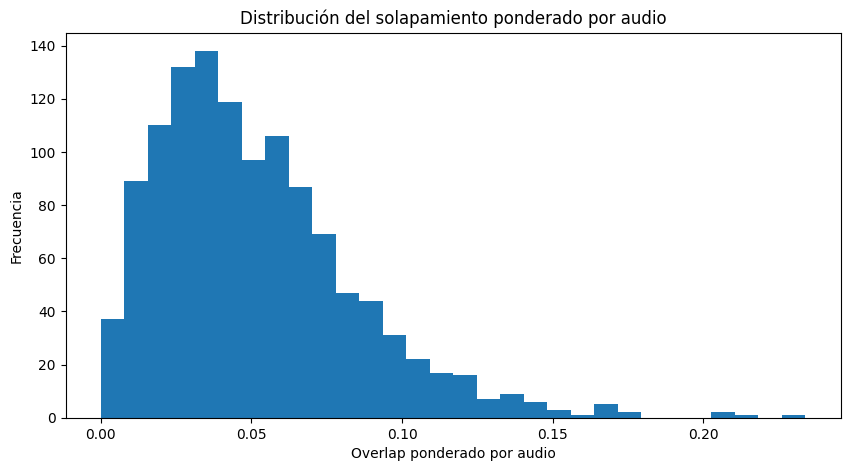

In [11]:
# =========================
# HISTOGRAMA DE OVERLAP PONDERADO POR AUDIO
# =========================

plt.figure(figsize=(10, 5))
plt.hist(df_audio_overlap_summary["audio_overlap_ratio_weighted"].dropna(), bins=30)
plt.xlabel("Overlap ponderado por audio")
plt.ylabel("Frecuencia")
plt.title("Distribución del solapamiento ponderado por audio")
plt.show()

## 7. Overlap de anchors actuales

In [12]:
# =========================
# OVERLAP DE ANCHORS ACTUALES
# =========================

df_anchors = df_all_anchor_segments.copy()
df_anchors["overlap_ratio"] = pd.to_numeric(df_anchors["overlap_ratio"], errors="coerce").fillna(0.0)

print("Resumen de overlap_ratio en anchors actuales:")
print(df_anchors["overlap_ratio"].describe())

anchor_rows = []
for threshold in OVERLAP_THRESHOLDS:
    anchor_rows.append({
        "threshold": threshold,
        "n_current_anchors_leq_threshold": int((df_anchors["overlap_ratio"] <= threshold).sum()),
        "pct_current_anchors_leq_threshold": float((df_anchors["overlap_ratio"] <= threshold).mean()) if len(df_anchors) else np.nan,
        "n_current_anchors_gt_threshold": int((df_anchors["overlap_ratio"] > threshold).sum()),
        "pct_current_anchors_gt_threshold": float((df_anchors["overlap_ratio"] > threshold).mean()) if len(df_anchors) else np.nan,
    })

df_current_anchor_overlap = pd.DataFrame(anchor_rows)
df_current_anchor_overlap

Resumen de overlap_ratio en anchors actuales:
count    7038.000000
mean        0.003890
std         0.010244
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.049960
Name: overlap_ratio, dtype: float64


,threshold,n_current_anchors_leq_threshold,pct_current_anchors_leq_threshold,n_current_anchors_gt_threshold,pct_current_anchors_gt_threshold
0,0.00,5752,0.817278,1286,0.182722
1,0.01,6133,0.871412,905,0.128588
2,0.03,6659,0.946149,379,0.053851
3,0.05,7038,1.000000,0,0.000000
4,0.10,7038,1.000000,0,0.000000
5,0.15,7038,1.000000,0,0.000000
6,0.20,7038,1.000000,0,0.000000
7,0.30,7038,1.000000,0,0.000000


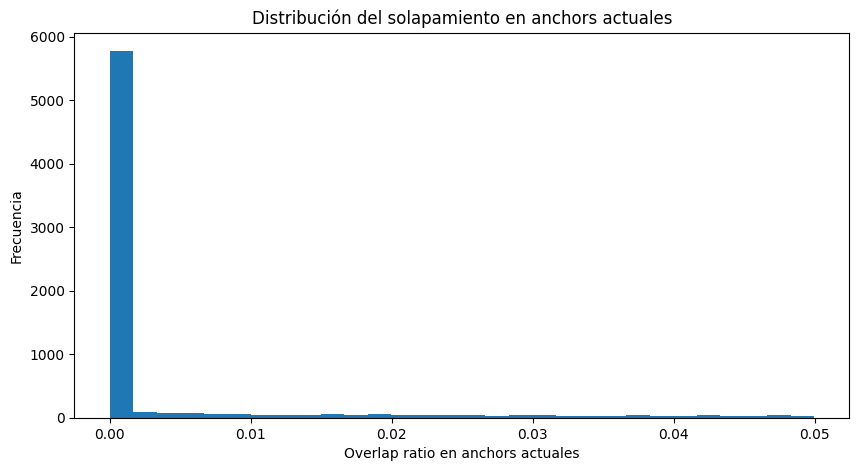

In [13]:
# =========================
# HISTOGRAMA DE OVERLAP EN ANCHORS ACTUALES
# =========================

plt.figure(figsize=(10, 5))
plt.hist(df_anchors["overlap_ratio"], bins=30)
plt.xlabel("Overlap ratio en anchors actuales")
plt.ylabel("Frecuencia")
plt.title("Distribución del solapamiento en anchors actuales")
plt.show()

## 8. Simulación de umbrales para selección de anchors

In [14]:
# =========================
# SIMULACIÓN DE UMBRALES PARA ANCHORS
# =========================

base_anchor_candidates = df_segments[
    (df_segments["duration"] >= MIN_ANCHOR_DURATION_SEC) &
    (df_segments["rms_dbfs"] >= MIN_RMS_DBFS) &
    (df_segments["start"] >= INITIAL_EXCLUDE_SEC_FOR_ANCHORS)
].copy()

print(f"Segmentos puntuados totales: {len(df_segments)}")
print(f"Candidatos base a anchor antes de filtro de overlap: {len(base_anchor_candidates)}")

threshold_summary_rows = []
total_audios = df_segments["audio_file"].nunique()

for threshold in OVERLAP_THRESHOLDS:
    df_candidates_t = base_anchor_candidates[base_anchor_candidates["overlap_ratio"] <= threshold].copy()

    candidate_counts = (
        df_candidates_t
        .groupby(["audio_file", "speaker"], dropna=False)
        .size()
        .reset_index(name="n_anchor_candidates")
    )

    speakers_with_min = candidate_counts[candidate_counts["n_anchor_candidates"] >= ANCHORS_PER_SPEAKER]
    audio_speaker_coverage = (
        speakers_with_min
        .groupby("audio_file")
        .size()
        .reset_index(name="n_speakers_with_min_anchors")
    )

    audios_with_any_anchor = df_candidates_t["audio_file"].nunique()
    audios_with_enough_anchors_both_speakers = int(
        (audio_speaker_coverage["n_speakers_with_min_anchors"] >= NUM_SPEAKERS).sum()
    ) if not audio_speaker_coverage.empty else 0

    anchors_per_audio = df_candidates_t.groupby("audio_file").size()

    threshold_summary_rows.append({
        "threshold": threshold,
        "n_candidate_anchor_segments": len(df_candidates_t),
        "pct_base_candidates_kept": safe_rate(len(df_candidates_t), len(base_anchor_candidates)),
        "audios_total": total_audios,
        "audios_with_any_anchor": audios_with_any_anchor,
        "pct_audios_with_any_anchor": safe_rate(audios_with_any_anchor, total_audios),
        "audios_without_any_anchor": total_audios - audios_with_any_anchor,
        "audios_with_min_anchors_both_speakers": audios_with_enough_anchors_both_speakers,
        "pct_audios_with_min_anchors_both_speakers": safe_rate(audios_with_enough_anchors_both_speakers, total_audios),
        "mean_anchor_candidates_per_audio": anchors_per_audio.mean() if len(anchors_per_audio) else 0,
        "median_anchor_candidates_per_audio": anchors_per_audio.median() if len(anchors_per_audio) else 0,
        "min_anchor_candidates_per_audio": anchors_per_audio.min() if len(anchors_per_audio) else 0,
        "max_anchor_candidates_per_audio": anchors_per_audio.max() if len(anchors_per_audio) else 0,
    })

df_threshold_summary = pd.DataFrame(threshold_summary_rows)
df_threshold_summary.to_csv(THRESHOLD_SUMMARY_CSV, index=False)
df_threshold_summary

Segmentos puntuados totales: 73000
Candidatos base a anchor antes de filtro de overlap: 34973


,threshold,n_candidate_anchor_segments,pct_base_candidates_kept,audios_total,audios_with_any_anchor,pct_audios_with_any_anchor,audios_without_any_anchor,audios_with_min_anchors_both_speakers,pct_audios_with_min_anchors_both_speakers,mean_anchor_candidates_per_audio,median_anchor_candidates_per_audio,min_anchor_candidates_per_audio,max_anchor_candidates_per_audio
0,0.00,22392,0.640265,1198,1198,1.0,0,1069,0.892321,18.691152,18.0,1,44
1,0.01,23671,0.676836,1198,1198,1.0,0,1094,0.913189,19.758765,19.0,3,44
2,0.03,25871,0.739742,1198,1198,1.0,0,1119,0.934057,21.595159,21.0,3,50
3,0.05,27306,0.780774,1198,1198,1.0,0,1128,0.941569,22.792988,22.0,3,50
4,0.10,29670,0.848369,1198,1198,1.0,0,1143,0.954090,24.766277,24.0,3,59
5,0.15,31083,0.888771,1198,1198,1.0,0,1150,0.959933,25.945743,25.0,3,65
6,0.20,32078,0.917222,1198,1198,1.0,0,1156,0.964942,26.776294,26.0,4,70
7,0.30,33181,0.948760,1198,1198,1.0,0,1162,0.969950,27.696995,27.0,4,74


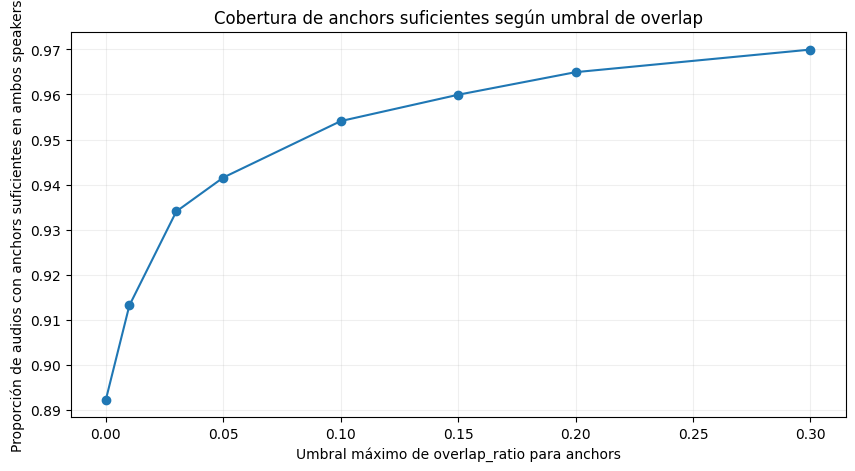

In [15]:
# =========================
# VISUALIZACIÓN DE COBERTURA POR UMBRAL
# =========================

plt.figure(figsize=(10, 5))
plt.plot(df_threshold_summary["threshold"], df_threshold_summary["pct_audios_with_min_anchors_both_speakers"], marker="o")
plt.xlabel("Umbral máximo de overlap_ratio para anchors")
plt.ylabel("Proporción de audios con anchors suficientes en ambos speakers")
plt.title("Cobertura de anchors suficientes según umbral de overlap")
plt.grid(alpha=0.2)
plt.show()

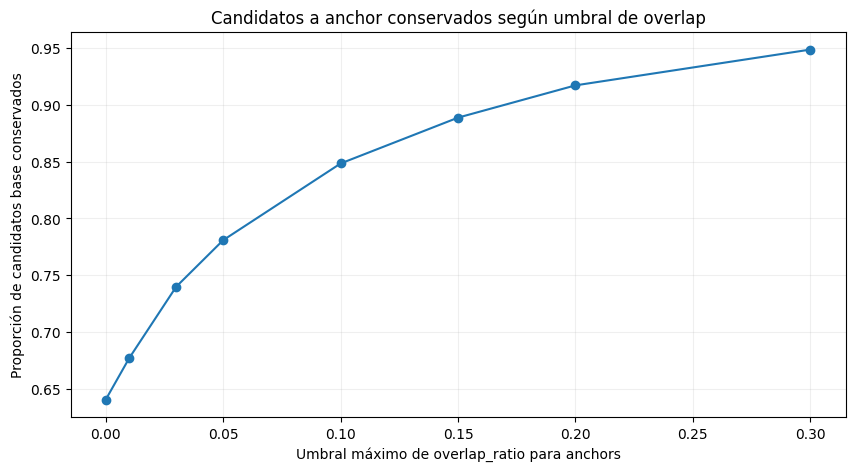

In [16]:
# =========================
# VISUALIZACIÓN DE CANDIDATOS CONSERVADOS POR UMBRAL
# =========================

plt.figure(figsize=(10, 5))
plt.plot(df_threshold_summary["threshold"], df_threshold_summary["pct_base_candidates_kept"], marker="o")
plt.xlabel("Umbral máximo de overlap_ratio para anchors")
plt.ylabel("Proporción de candidatos base conservados")
plt.title("Candidatos a anchor conservados según umbral de overlap")
plt.grid(alpha=0.2)
plt.show()

## 9. Recomendación automática preliminar del umbral de overlap

In [17]:
# =========================
# RECOMENDACIÓN PRELIMINAR DE UMBRAL
# =========================

MIN_ACCEPTABLE_AUDIO_COVERAGE = 0.90

eligible_thresholds = df_threshold_summary[
    df_threshold_summary["pct_audios_with_min_anchors_both_speakers"] >= MIN_ACCEPTABLE_AUDIO_COVERAGE
].copy()

if not eligible_thresholds.empty:
    recommended_threshold = eligible_thresholds.sort_values("threshold").iloc[0]["threshold"]
    recommendation_reason = (
        f"Se recomienda {recommended_threshold:.2f} porque es el umbral más estricto que mantiene "
        f"al menos {MIN_ACCEPTABLE_AUDIO_COVERAGE:.0%} de audios con anchors suficientes en ambos speakers."
    )
else:
    recommended_threshold = df_threshold_summary.sort_values("pct_audios_with_min_anchors_both_speakers", ascending=False).iloc[0]["threshold"]
    recommendation_reason = (
        f"Ningún umbral alcanza {MIN_ACCEPTABLE_AUDIO_COVERAGE:.0%} de cobertura. "
        f"El umbral con mayor cobertura es {recommended_threshold:.2f}."
    )

print("Umbral recomendado preliminar:", recommended_threshold)
print(recommendation_reason)

recommendation_path = OVERLAP_ANALYSIS_DIR / "overlap_threshold_recommendation.txt"
with open(recommendation_path, "w", encoding="utf-8") as f:
    f.write(f"recommended_threshold={recommended_threshold}")
    f.write(recommendation_reason + "")

print(f"Recomendación guardada en: {recommendation_path}")

Umbral recomendado preliminar: 0.01
Se recomienda 0.01 porque es el umbral más estricto que mantiene al menos 90% de audios con anchors suficientes en ambos speakers.
Recomendación guardada en: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs/overlap_analysis/overlap_threshold_recommendation.txt


## 10. Disponibilidad de anchors por audio y speaker según umbral

In [18]:
# =========================
# DISPONIBILIDAD DE ANCHORS POR AUDIO Y SPEAKER SEGÚN UMBRAL
# =========================

ANCHORS_PER_SPEAKER_TARGET = 3
anchor_thresholds = [0.00, 0.01, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30]

availability_rows = []

for threshold in anchor_thresholds:
    df_candidates = df_all_scored_segments[
        (df_all_scored_segments["valid_export"] == True) &
        (df_all_scored_segments["duration"] >= MIN_ANCHOR_DURATION_SEC) &
        (df_all_scored_segments["rms_dbfs"] >= MIN_RMS_DBFS) &
        (df_all_scored_segments["start"] >= INITIAL_EXCLUDE_SEC_FOR_ANCHORS) &
        (df_all_scored_segments["overlap_ratio"] <= threshold)
    ].copy()

    anchors_by_audio_speaker = (
        df_candidates
        .groupby(["audio_file", "speaker"])
        .size()
        .reset_index(name="n_candidate_anchors")
    )

    n_audio_speaker_pairs = anchors_by_audio_speaker.shape[0]
    n_pairs_with_min_anchors = (
        anchors_by_audio_speaker["n_candidate_anchors"] >= ANCHORS_PER_SPEAKER_TARGET
    ).sum()

    anchors_by_audio = (
        anchors_by_audio_speaker
        .groupby("audio_file")
        .agg(
            n_speakers_with_candidates=("speaker", "nunique"),
            min_anchors_per_speaker=("n_candidate_anchors", "min"),
            total_candidate_anchors=("n_candidate_anchors", "sum")
        )
        .reset_index()
    )

    n_audios_with_any_anchor = anchors_by_audio["audio_file"].nunique()

    n_audios_with_two_speakers = (
        anchors_by_audio["n_speakers_with_candidates"] >= 2
    ).sum()

    n_audios_with_3_per_speaker = (
        (anchors_by_audio["n_speakers_with_candidates"] >= 2) &
        (anchors_by_audio["min_anchors_per_speaker"] >= ANCHORS_PER_SPEAKER_TARGET)
    ).sum()

    availability_rows.append({
        "threshold": threshold,
        "candidate_anchor_segments": len(df_candidates),
        "audio_speaker_pairs_with_candidates": n_audio_speaker_pairs,
        "audio_speaker_pairs_with_at_least_3": n_pairs_with_min_anchors,
        "audios_with_any_anchor": n_audios_with_any_anchor,
        "audios_with_two_speakers_with_candidates": n_audios_with_two_speakers,
        "audios_with_at_least_3_anchors_per_speaker": n_audios_with_3_per_speaker,
        "pct_audios_with_at_least_3_anchors_per_speaker": (
            n_audios_with_3_per_speaker / df_summary["audio_file"].nunique()
            if df_summary["audio_file"].nunique() > 0 else np.nan
        )
    })

df_anchor_availability_by_threshold = pd.DataFrame(availability_rows)

df_anchor_availability_by_threshold

,threshold,candidate_anchor_segments,audio_speaker_pairs_with_candidates,audio_speaker_pairs_with_at_least_3,audios_with_any_anchor,audios_with_two_speakers_with_candidates,audios_with_at_least_3_anchors_per_speaker,pct_audios_with_at_least_3_anchors_per_speaker
0,0.00,22392,2375,2264,1198,1177,1069,0.892321
1,0.01,23671,2380,2290,1198,1182,1094,0.913189
2,0.03,25871,2382,2317,1198,1184,1119,0.934057
3,0.05,27306,2382,2326,1198,1184,1128,0.941569
4,0.10,29670,2385,2341,1198,1187,1143,0.954090
5,0.15,31083,2386,2348,1198,1188,1150,0.959933
6,0.20,32078,2387,2354,1198,1189,1156,0.964942
7,0.30,33181,2387,2360,1198,1189,1162,0.969950


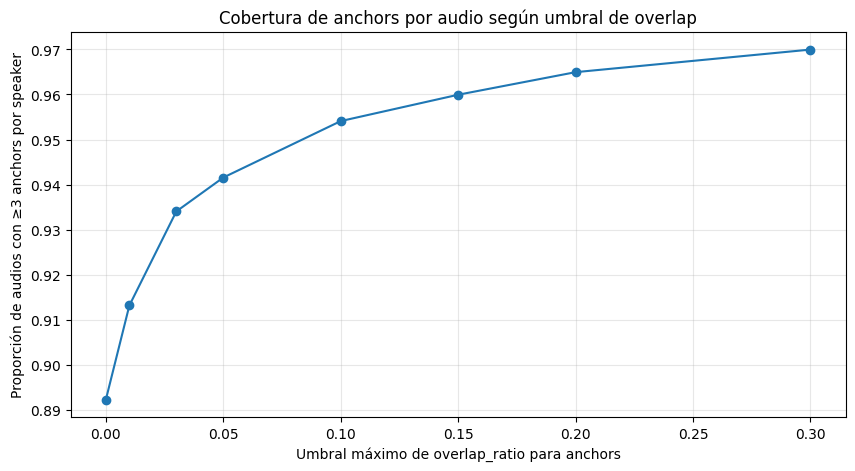

In [19]:
# =========================
# EFECTO DEL UMBRAL SOBRE LA COBERTURA DE AUDIOS
# =========================

plt.figure(figsize=(10, 5))
plt.plot(
    df_anchor_availability_by_threshold["threshold"],
    df_anchor_availability_by_threshold["pct_audios_with_at_least_3_anchors_per_speaker"],
    marker="o"
)
plt.xlabel("Umbral máximo de overlap_ratio para anchors")
plt.ylabel("Proporción de audios con ≥3 anchors por speaker")
plt.title("Cobertura de anchors por audio según umbral de overlap")
plt.grid(alpha=0.3)
plt.show()

## 11. Subida de resultados del análisis de overlap a GCS

In [20]:
# =========================
# SUBIDA DE RESULTADOS A GCS
# =========================

files_to_upload = [
    THRESHOLD_SUMMARY_CSV,
    AUDIO_OVERLAP_SUMMARY_CSV,
    SEGMENT_OVERLAP_DISTRIBUTION_CSV,
    OVERLAP_ANALYSIS_DIR / "overlap_threshold_recommendation.txt",
]

uploaded_uris = []
for local_path in files_to_upload:
    if local_path.exists():
        uri = upload_file_to_gcs(local_path, GCS_DIARIZATION_OUTPUT_PREFIX)
        uploaded_uris.append(uri)
        print(f"Subido: {uri}")
    else:
        print(f"No existe, no se sube: {local_path}")

print("Subida finalizada.")

Subido: gs://catedras_audio_detection/pipelineA/procesados_UNAV/diarization_outputs/overlap_analysis/overlap_threshold_summary.csv
Subido: gs://catedras_audio_detection/pipelineA/procesados_UNAV/diarization_outputs/overlap_analysis/audio_overlap_summary.csv
Subido: gs://catedras_audio_detection/pipelineA/procesados_UNAV/diarization_outputs/overlap_analysis/segment_overlap_distribution.csv
Subido: gs://catedras_audio_detection/pipelineA/procesados_UNAV/diarization_outputs/overlap_analysis/overlap_threshold_recommendation.txt
Subida finalizada.


## 12. Resumen ejecutivo del análisis de overlap

In [21]:
print("Resumen ejecutivo para documentar:")
print()
print(f"Segmentos puntuados analizados: {len(df_segments)}")
print(f"Audios analizados: {df_segments['audio_file'].nunique()}")
print(f"Candidatos base a anchor antes de overlap: {len(base_anchor_candidates)}")
print(f"Umbral recomendado preliminar: {recommended_threshold}")
print()
print("Tabla de umbrales:")
df_threshold_summary

Resumen ejecutivo para documentar:

Segmentos puntuados analizados: 73000
Audios analizados: 1198
Candidatos base a anchor antes de overlap: 34973
Umbral recomendado preliminar: 0.01

Tabla de umbrales:


,threshold,n_candidate_anchor_segments,pct_base_candidates_kept,audios_total,audios_with_any_anchor,pct_audios_with_any_anchor,audios_without_any_anchor,audios_with_min_anchors_both_speakers,pct_audios_with_min_anchors_both_speakers,mean_anchor_candidates_per_audio,median_anchor_candidates_per_audio,min_anchor_candidates_per_audio,max_anchor_candidates_per_audio
0,0.00,22392,0.640265,1198,1198,1.0,0,1069,0.892321,18.691152,18.0,1,44
1,0.01,23671,0.676836,1198,1198,1.0,0,1094,0.913189,19.758765,19.0,3,44
2,0.03,25871,0.739742,1198,1198,1.0,0,1119,0.934057,21.595159,21.0,3,50
3,0.05,27306,0.780774,1198,1198,1.0,0,1128,0.941569,22.792988,22.0,3,50
4,0.10,29670,0.848369,1198,1198,1.0,0,1143,0.954090,24.766277,24.0,3,59
5,0.15,31083,0.888771,1198,1198,1.0,0,1150,0.959933,25.945743,25.0,3,65
6,0.20,32078,0.917222,1198,1198,1.0,0,1156,0.964942,26.776294,26.0,4,70
7,0.30,33181,0.948760,1198,1198,1.0,0,1162,0.969950,27.696995,27.0,4,74


## 13. Sensibilidad del margen de reetiquetado (`RELABEL_MIN_MARGIN`)

Esta sección lee los archivos `*_final_segments.csv` ya generados por el Notebook 01, usa las columnas de distancia contra centroides (`dist_SPEAKER_*`) y simula distintos valores de `RELABEL_MIN_MARGIN` para comparar cuántos segmentos se reetiquetarían con cada margen.

No recalcula embeddings, no modifica los CSVs originales del Notebook 01 y no reescribe el pipeline principal.

In [22]:
# ============================================================
# CELDA 3 - EJECUTAR SENSIBILIDAD DE RELABEL_MIN_MARGIN
# ============================================================

final_segment_files = find_final_segment_files(FINAL_RELABEL_DIR)

print("Archivos *_final_segments.csv encontrados:", len(final_segment_files))

if len(final_segment_files) == 0:
    raise FileNotFoundError(
        "Todavía no hay *_final_segments.csv en FINAL_RELABEL_DIR. "
        "Corre este notebook cuando el Notebook 01 ya haya generado al menos algunos resultados finales."
    )

all_margin_rows = []
summary_rows = []
skipped_files = []

for idx, file_path in enumerate(final_segment_files, start=1):
    print(f"[{idx}/{len(final_segment_files)}] {file_path.name}")

    try:
        df_audio = pd.read_csv(file_path)

        if df_audio.empty:
            skipped_files.append({"file": str(file_path), "reason": "empty_csv"})
            continue

        audio_file = (
            df_audio["audio_file"].iloc[0]
            if "audio_file" in df_audio.columns
            else file_path.name.replace("_final_segments.csv", ".wav")
        )

        df_audio = infer_best_speaker_from_distances(df_audio)

        if "speaker_original" in df_audio.columns:
            original_col = "speaker_original"
        elif "speaker" in df_audio.columns:
            original_col = "speaker"
        else:
            skipped_files.append({"file": str(file_path), "reason": "missing_speaker_column"})
            continue

        for margin in RELABEL_MARGIN_OPTIONS:
            df_margin = apply_relabel_margin(df_audio, margin)

            n_segments = len(df_margin)
            n_changed = int(df_margin["was_reclassified_margin"].sum())
            n_merged = count_merged_segments(
                df_margin,
                speaker_col="speaker_final_margin",
                max_gap_sec=MAX_GAP_MERGE_SEC,
            )

            summary_rows.append({
                "audio_file": audio_file,
                "source_csv": file_path.name,
                "tested_relabel_margin": margin,
                "n_segments": n_segments,
                "n_changed_segments": n_changed,
                "changed_ratio": n_changed / n_segments if n_segments else np.nan,
                "n_final_merged_segments": n_merged,
                "mean_distance_margin": df_margin["distance_margin_recomputed"].mean(),
                "median_distance_margin": df_margin["distance_margin_recomputed"].median(),
                "min_distance_margin": df_margin["distance_margin_recomputed"].min(),
                "max_distance_margin": df_margin["distance_margin_recomputed"].max(),
            })

            keep_cols = [
                "audio_file",
                "segment_id_raw",
                "start",
                "end",
                "duration",
                original_col,
                "best_speaker_recomputed",
                "best_distance_recomputed",
                "second_distance_recomputed",
                "distance_margin_recomputed",
                "tested_relabel_margin",
                "speaker_final_margin",
                "was_reclassified_margin",
                "relabel_source_margin",
            ]

            keep_cols = [c for c in keep_cols if c in df_margin.columns]
            detail_tmp = df_margin[keep_cols].copy()
            detail_tmp["source_csv"] = file_path.name
            all_margin_rows.append(detail_tmp)

    except Exception as e:
        skipped_files.append({"file": str(file_path), "reason": str(e)})

if not summary_rows:
    raise RuntimeError("No se pudo procesar ningún archivo final_segments con columnas de distancia.")

# Detalle y resumen por audio
if all_margin_rows:
    df_relabel_margin_detail = pd.concat(all_margin_rows, ignore_index=True)
else:
    df_relabel_margin_detail = pd.DataFrame()

df_relabel_margin_by_audio = pd.DataFrame(summary_rows)
df_relabel_margin_skipped = pd.DataFrame(skipped_files)

# Resumen global por margen
df_relabel_margin_summary = (
    df_relabel_margin_by_audio
    .groupby("tested_relabel_margin", as_index=False)
    .agg(
        n_audios=("audio_file", "nunique"),
        n_segments=("n_segments", "sum"),
        n_changed_segments=("n_changed_segments", "sum"),
        mean_changed_ratio_by_audio=("changed_ratio", "mean"),
        median_changed_ratio_by_audio=("changed_ratio", "median"),
        total_final_merged_segments=("n_final_merged_segments", "sum"),
        mean_final_merged_segments_by_audio=("n_final_merged_segments", "mean"),
        mean_distance_margin=("mean_distance_margin", "mean"),
        median_distance_margin=("median_distance_margin", "median"),
    )
)

df_relabel_margin_summary["global_changed_ratio"] = (
    df_relabel_margin_summary["n_changed_segments"]
    / df_relabel_margin_summary["n_segments"]
)

# Comparación contra margen actual
CURRENT_RELABEL_MIN_MARGIN = 0.01
baseline_mask = df_relabel_margin_summary["tested_relabel_margin"] == CURRENT_RELABEL_MIN_MARGIN

if baseline_mask.any():
    baseline = df_relabel_margin_summary.loc[baseline_mask].iloc[0]
    df_relabel_margin_summary["delta_changed_segments_vs_current"] = (
        df_relabel_margin_summary["n_changed_segments"] - baseline["n_changed_segments"]
    )
    df_relabel_margin_summary["delta_global_changed_ratio_vs_current"] = (
        df_relabel_margin_summary["global_changed_ratio"] - baseline["global_changed_ratio"]
    )
    df_relabel_margin_summary["delta_merged_segments_vs_current"] = (
        df_relabel_margin_summary["total_final_merged_segments"] - baseline["total_final_merged_segments"]
    )

# Guardar resultados locales
DETAIL_CSV = MARGIN_ANALYSIS_DIR / "relabel_margin_sensitivity_detail.csv"
BY_AUDIO_CSV = MARGIN_ANALYSIS_DIR / "relabel_margin_sensitivity_by_audio.csv"
SUMMARY_CSV = MARGIN_ANALYSIS_DIR / "relabel_margin_sensitivity_summary.csv"
SKIPPED_CSV = MARGIN_ANALYSIS_DIR / "relabel_margin_sensitivity_skipped_files.csv"

if not df_relabel_margin_detail.empty:
    df_relabel_margin_detail.to_csv(DETAIL_CSV, index=False)

df_relabel_margin_by_audio.to_csv(BY_AUDIO_CSV, index=False)
df_relabel_margin_summary.to_csv(SUMMARY_CSV, index=False)

if not df_relabel_margin_skipped.empty:
    df_relabel_margin_skipped.to_csv(SKIPPED_CSV, index=False)

print("\nGuardado local:")
if not df_relabel_margin_detail.empty:
    print(DETAIL_CSV)
print(BY_AUDIO_CSV)
print(SUMMARY_CSV)
if not df_relabel_margin_skipped.empty:
    print(SKIPPED_CSV)

# Subida opcional a GCS
if UPLOAD_TO_GCS:
    outputs_to_upload = [BY_AUDIO_CSV, SUMMARY_CSV]
    if not df_relabel_margin_detail.empty:
        outputs_to_upload.append(DETAIL_CSV)
    if not df_relabel_margin_skipped.empty:
        outputs_to_upload.append(SKIPPED_CSV)

    upload_outputs_to_gcs(outputs_to_upload, GCS_BUCKET_NAME, GCS_CSV_PREFIX)

# Mostrar tabla resumen
cols_to_show = [
    "tested_relabel_margin",
    "n_audios",
    "n_segments",
    "n_changed_segments",
    "global_changed_ratio",
    "mean_changed_ratio_by_audio",
    "median_changed_ratio_by_audio",
    "total_final_merged_segments",
    "mean_final_merged_segments_by_audio",
    "mean_distance_margin",
    "median_distance_margin",
    "delta_changed_segments_vs_current",
    "delta_global_changed_ratio_vs_current",
    "delta_merged_segments_vs_current",
]
cols_to_show = [c for c in cols_to_show if c in df_relabel_margin_summary.columns]

df_relabel_margin_summary[cols_to_show]


Archivos *_final_segments.csv encontrados: 1181
[1/1181] raw_9154117451310006851_clean_final_segments.csv
[2/1181] raw_9154117551220006851_clean_final_segments.csv
[3/1181] raw_9154127337680006851_clean_final_segments.csv
[4/1181] raw_9154142438160016851_clean_final_segments.csv
[5/1181] raw_9154152155960016851_clean_final_segments.csv
[6/1181] raw_9154188548830006851_clean_final_segments.csv
[7/1181] raw_9154202560160006851_clean_final_segments.csv
[8/1181] raw_9154202749900006851_clean_final_segments.csv
[9/1181] raw_9154219744450006851_clean_final_segments.csv
[10/1181] raw_9154222339820016851_clean_final_segments.csv
[11/1181] raw_9154281474720016851_clean_final_segments.csv
[12/1181] raw_9154281641250016851_clean_final_segments.csv
[13/1181] raw_9154291167650006851_clean_final_segments.csv
[14/1181] raw_9154334371160016851_clean_final_segments.csv
[15/1181] raw_9154334697630006851_clean_final_segments.csv
[16/1181] raw_9154340242110006851_clean_final_segments.csv
[17/1181] raw_915

,tested_relabel_margin,n_audios,n_segments,n_changed_segments,global_changed_ratio,mean_changed_ratio_by_audio,median_changed_ratio_by_audio,total_final_merged_segments,mean_final_merged_segments_by_audio,mean_distance_margin,median_distance_margin,delta_changed_segments_vs_current,delta_global_changed_ratio_vs_current,delta_merged_segments_vs_current
0,0.000,1181,43493,3943,0.090658,0.092358,0.058824,40289,34.114310,0.34634,0.377851,243.0,0.005587,-63.0
1,0.005,1181,43493,3825,0.087945,0.089528,0.057143,40320,34.140559,0.34634,0.377851,125.0,0.002874,-32.0
2,0.010,1181,43493,3700,0.085071,0.086518,0.055556,40352,34.167655,0.34634,0.377851,0.0,0.000000,0.0
3,0.020,1181,43493,3484,0.080105,0.081224,0.051282,40393,34.202371,0.34634,0.377851,-216.0,-0.004966,41.0
4,0.030,1181,43493,3287,0.075575,0.076460,0.047619,40438,34.240474,0.34634,0.377851,-413.0,-0.009496,86.0
5,0.050,1181,43493,2917,0.067068,0.067649,0.041667,40558,34.342083,0.34634,0.377851,-783.0,-0.018003,206.0
6,0.100,1181,43493,2153,0.049502,0.049637,0.032258,40764,34.516511,0.34634,0.377851,-1547.0,-0.035569,412.0


## Cómo leer la tabla

- `tested_relabel_margin`: margen probado.
- `n_changed_segments`: segmentos que se reetiquetarían con ese margen.
- `global_changed_ratio`: porcentaje global de segmentos reetiquetados.
- `total_final_merged_segments`: cantidad aproximada de segmentos finales si se aplicara ese margen y luego se unieran segmentos consecutivos del mismo speaker.
- Las columnas `delta_*_vs_current` comparan cada margen contra `0.01`, que es el margen usado actualmente en el Notebook 01.

Lectura esperada:

- `0.00` será el más permisivo: cambia más segmentos.
- `0.01` es el valor actual.
- `0.05` o `0.10` serán más conservadores: cambian menos segmentos.

Este notebook solo sirve para justificar sensibilidad. No modifica los CSVs originales del pipeline principal.
